In [1]:
# ==============================================================================
# MULTI-MODEL EVALUATION: 5 Skin Lesion Classifiers
# Models: DenseNet121-focal-loss, skin-lesion-densenet121,
#         skin-lesion-mobileNetv2, skin-lesion-resnet18, skin-lesion-resnet50
# Metrics: Accuracy, F1, Precision, Recall, ROC-AUC + Confusion Matrix
# ==============================================================================

# ==============================================================================
# 1. SETUP
# ==============================================================================
!pip install -q transformers datasets evaluate accelerate torchvision scikit-learn seaborn
 
import os
 
# Force single GPU — must be set BEFORE torch is used
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
 
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader
from torchvision.transforms import Compose
 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
Using device: cuda:0


In [6]:
# ==============================================================================
# 2. MODELS TO EVALUATE
# ==============================================================================
MODEL_IDS = [
    "KaushalXD/DenseNet121-focal-loss-v2",
    "KaushalXD/DenseNet121-focal-loss",
    "KaushalXD/skin-lesion-densenet121",
    "KaushalXD/skin-lesion-mobileNetv2",
    "KaushalXD/skin-lesion-resnet18",
    "KaushalXD/skin-lesion-resnet50",
]

SHORT_NAMES = [
    "DenseNet121-focal-loss-v2",
    "DenseNet121-FocalLoss",
    "DenseNet121",
    "MobileNetV2",
    "ResNet18",
    "ResNet50",
]




In [7]:
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    DefaultDataCollator, # Add this line
)

In [8]:
# ==============================================================================
# 3. DATASET
# ==============================================================================
print("\nLoading dataset...")
dataset = load_dataset("ahmed-ai/skin-lesions-classification-dataset")
target_names = dataset["test"].features["label"].names
num_classes = len(target_names)
print(f"Classes ({num_classes}): {target_names}")

data_collator = DefaultDataCollator()





Loading dataset...


Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Classes (14): ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']


In [9]:
# ==============================================================================
# 4. INFERENCE — plain PyTorch loop (no Trainer, no DataParallel)
# ==============================================================================
def run_inference(model_id):
    """Load model, run inference on test set, return (true_labels, pred_labels, probs)."""
 
    print(f"  Loading processor & model...")
    processor = AutoImageProcessor.from_pretrained(model_id)
    model     = AutoModelForImageClassification.from_pretrained(model_id)
    model.to(device)
    model.eval()
 
    all_logits = []
    all_labels = []
 
    test_data = dataset["test"]
    batch_size = 32
 
    print(f"  Running inference on {len(test_data)} samples...")
    for start in range(0, len(test_data), batch_size):
        batch = test_data.select(range(start, min(start + batch_size, len(test_data))))
 
        images = [img.convert("RGB") for img in batch["image"]]
        labels = batch["label"]
 
        inputs = processor(images=images, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
 
        with torch.no_grad():
            outputs = model(**inputs)
 
        all_logits.append(outputs.logits.cpu())
        all_labels.extend(labels)
 
        if (start // batch_size) % 10 == 0:
            print(f"    Processed {min(start + batch_size, len(test_data))}/{len(test_data)}")
 
    logits      = torch.cat(all_logits, dim=0)                          # (N, C)
    probs       = torch.softmax(logits, dim=1).numpy()                  # (N, C)
    pred_labels = np.argmax(probs, axis=1)                              # (N,)
    true_labels = np.array(all_labels)                                  # (N,)
 
    del model
    torch.cuda.empty_cache()
 
    return true_labels, pred_labels, probs

In [10]:
# ==============================================================================
# 5. METRICS
# ==============================================================================
def compute_all_metrics(true_labels, pred_labels, probs):
    acc  = accuracy_score(true_labels, pred_labels)
    f1_w = f1_score(true_labels, pred_labels, average="weighted", zero_division=0)
    f1_m = f1_score(true_labels, pred_labels, average="macro",    zero_division=0)
    pre  = precision_score(true_labels, pred_labels, average="weighted", zero_division=0)
    rec  = recall_score(true_labels, pred_labels, average="weighted",    zero_division=0)
 
    try:
        y_bin = label_binarize(true_labels, classes=list(range(num_classes)))
        auc   = roc_auc_score(y_bin, probs, average="weighted", multi_class="ovr")
    except Exception:
        auc = float("nan")
 
    return {
        "Accuracy":             round(acc,  4),
        "F1 (Weighted)":        round(f1_w, 4),
        "F1 (Macro)":           round(f1_m, 4),
        "Precision (Weighted)": round(pre,  4),
        "Recall (Weighted)":    round(rec,  4),
        "ROC-AUC (Weighted)":   round(auc,  4),
    }

In [11]:
# ==============================================================================
# 6. MAIN LOOP
# ==============================================================================
all_results = {}
all_reports = {}
all_true    = {}
all_pred    = {}
all_probs   = {}
 
for model_id, short_name in zip(MODEL_IDS, SHORT_NAMES):
    print(f"\n{'='*60}")
    print(f"Evaluating: {short_name}")
    print(f"  HF ID: {model_id}")
    print(f"{'='*60}")
 
    try:
        true_labels, pred_labels, probs = run_inference(model_id)
 
        metrics = compute_all_metrics(true_labels, pred_labels, probs)
        report  = classification_report(
            true_labels, pred_labels,
            target_names=target_names,
            zero_division=0,
        )
 
        all_results[short_name] = metrics
        all_reports[short_name] = report
        all_true[short_name]    = true_labels
        all_pred[short_name]    = pred_labels
        all_probs[short_name]   = probs
 
        print(f"\n✅ {short_name} done!")
        print(f"   Metrics : {metrics}")
        print(f"\n{report}")
 
    except Exception as e:
        import traceback
        print(f"\n❌ FAILED: {short_name}")
        traceback.print_exc()
        all_results[short_name] = {}
        torch.cuda.empty_cache()
 
 


Evaluating: DenseNet121-focal-loss-v2
  HF ID: KaushalXD/DenseNet121-focal-loss-v2
  Loading processor & model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/28.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

  Running inference on 3674 samples...
    Processed 32/3674
    Processed 352/3674
    Processed 672/3674
    Processed 992/3674
    Processed 1312/3674
    Processed 1632/3674
    Processed 1952/3674
    Processed 2272/3674
    Processed 2592/3674
    Processed 2912/3674
    Processed 3232/3674
    Processed 3552/3674

✅ DenseNet121-focal-loss-v2 done!
   Metrics : {'Accuracy': 0.8702, 'F1 (Weighted)': 0.8724, 'F1 (Macro)': 0.8507, 'Precision (Weighted)': 0.8772, 'Recall (Weighted)': 0.8702, 'ROC-AUC (Weighted)': np.float64(0.9836)}

                               precision    recall  f1-score   support

            Actinic keratoses       0.61      0.68      0.64        88
         Basal cell carcinoma       0.85      0.89      0.87       333
Benign keratosis-like lesions       0.72      0.76      0.74       263
                   Chickenpox       0.89      1.00      0.94       113
                       Cowpox       0.98      1.00      0.99        99
               Dermatofibroma  

...

preprocessor_config.json:   0%|          | 0.00/391 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/94.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

  Running inference on 3674 samples...
    Processed 32/3674
    Processed 352/3674
    Processed 672/3674
    Processed 992/3674
    Processed 1312/3674
    Processed 1632/3674
    Processed 1952/3674
    Processed 2272/3674
    Processed 2592/3674
    Processed 2912/3674
    Processed 3232/3674
    Processed 3552/3674

✅ ResNet50 done!
   Metrics : {'Accuracy': 0.7158, 'F1 (Weighted)': 0.7318, 'F1 (Macro)': 0.6662, 'Precision (Weighted)': 0.765, 'Recall (Weighted)': 0.7158, 'ROC-AUC (Weighted)': np.float64(0.9531)}

                               precision    recall  f1-score   support

            Actinic keratoses       0.31      0.61      0.41        88
         Basal cell carcinoma       0.68      0.61      0.64       333
Benign keratosis-like lesions       0.44      0.48      0.46       263
                   Chickenpox       0.70      0.95      0.80       113
                       Cowpox       0.83      0.94      0.88        99
               Dermatofibroma       0.11      0.3

In [12]:
# ==============================================================================
# 7. SUMMARY TABLE
# ==============================================================================
print("\n" + "=" * 70)
print("SUMMARY TABLE — ALL MODELS")
print("=" * 70)
 
successful = {k: v for k, v in all_results.items() if v}
failed     = [k for k, v in all_results.items() if not v]
 
if failed:
    print(f"\n⚠️  Failed models: {failed}")
 
if not successful:
    print("❌ No models evaluated successfully.")
else:
    summary_df = pd.DataFrame(successful).T
    summary_df = summary_df.sort_values("F1 (Weighted)", ascending=False)
    print(f"\n{summary_df.to_string()}")
    summary_df.to_csv("/kaggle/working/model_comparison_summary.csv")
    print("\nSaved → /kaggle/working/model_comparison_summary.csv")


SUMMARY TABLE — ALL MODELS

                           Accuracy  F1 (Weighted)  F1 (Macro)  Precision (Weighted)  Recall (Weighted)  ROC-AUC (Weighted)
DenseNet121-focal-loss-v2    0.8702         0.8724      0.8507                0.8772             0.8702              0.9836
DenseNet121                  0.8669         0.8627      0.8299                0.8641             0.8669              0.9789
DenseNet121-FocalLoss        0.8498         0.8521      0.8205                0.8571             0.8498              0.9802
ResNet18                     0.8427         0.8405      0.8056                0.8404             0.8427              0.9768
ResNet50                     0.7158         0.7318      0.6662                0.7650             0.7158              0.9531
MobileNetV2                  0.4069         0.4326      0.3088                0.5107             0.4069              0.8625

Saved → /kaggle/working/model_comparison_summary.csv


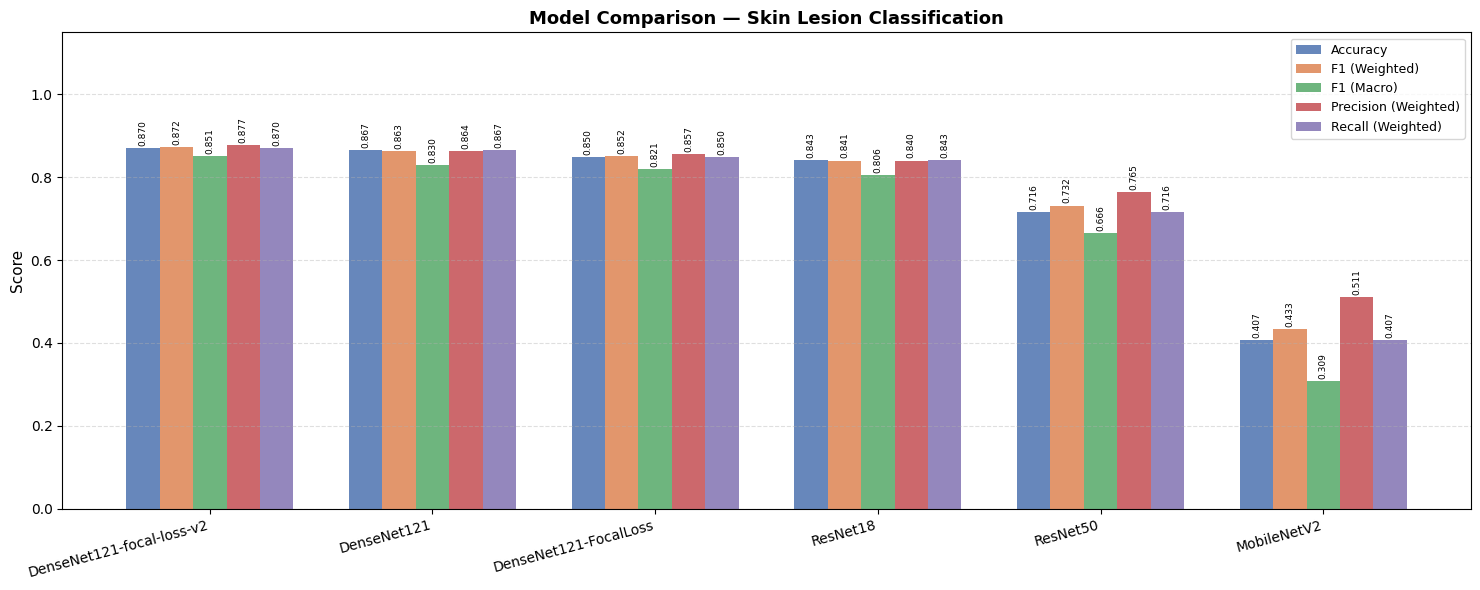

Saved → /kaggle/working/model_comparison_bar.png


In [13]:
# ==============================================================================
# 8. BAR CHART — all metrics side by side
# ==============================================================================
if successful:
    metrics_to_plot = [
        "Accuracy", "F1 (Weighted)", "F1 (Macro)",
        "Precision (Weighted)", "Recall (Weighted)"
    ]
    plot_df = summary_df[metrics_to_plot].reset_index().rename(columns={"index": "Model"})
 
    fig, ax = plt.subplots(figsize=(15, 6))
    x         = np.arange(len(plot_df))
    bar_width  = 0.15
    colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
 
    for i, metric in enumerate(metrics_to_plot):
        vals = plot_df[metric].values.astype(float)
        bars = ax.bar(x + i * bar_width, vals, bar_width,
                      label=metric, color=colors[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=6.5, rotation=90,
            )
 
    ax.set_xticks(x + bar_width * (len(metrics_to_plot) - 1) / 2)
    ax.set_xticklabels(plot_df["Model"], fontsize=10, rotation=15, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title("Model Comparison — Skin Lesion Classification", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("/kaggle/working/model_comparison_bar.png", dpi=200)
    plt.show()
    print("Saved → /kaggle/working/model_comparison_bar.png")

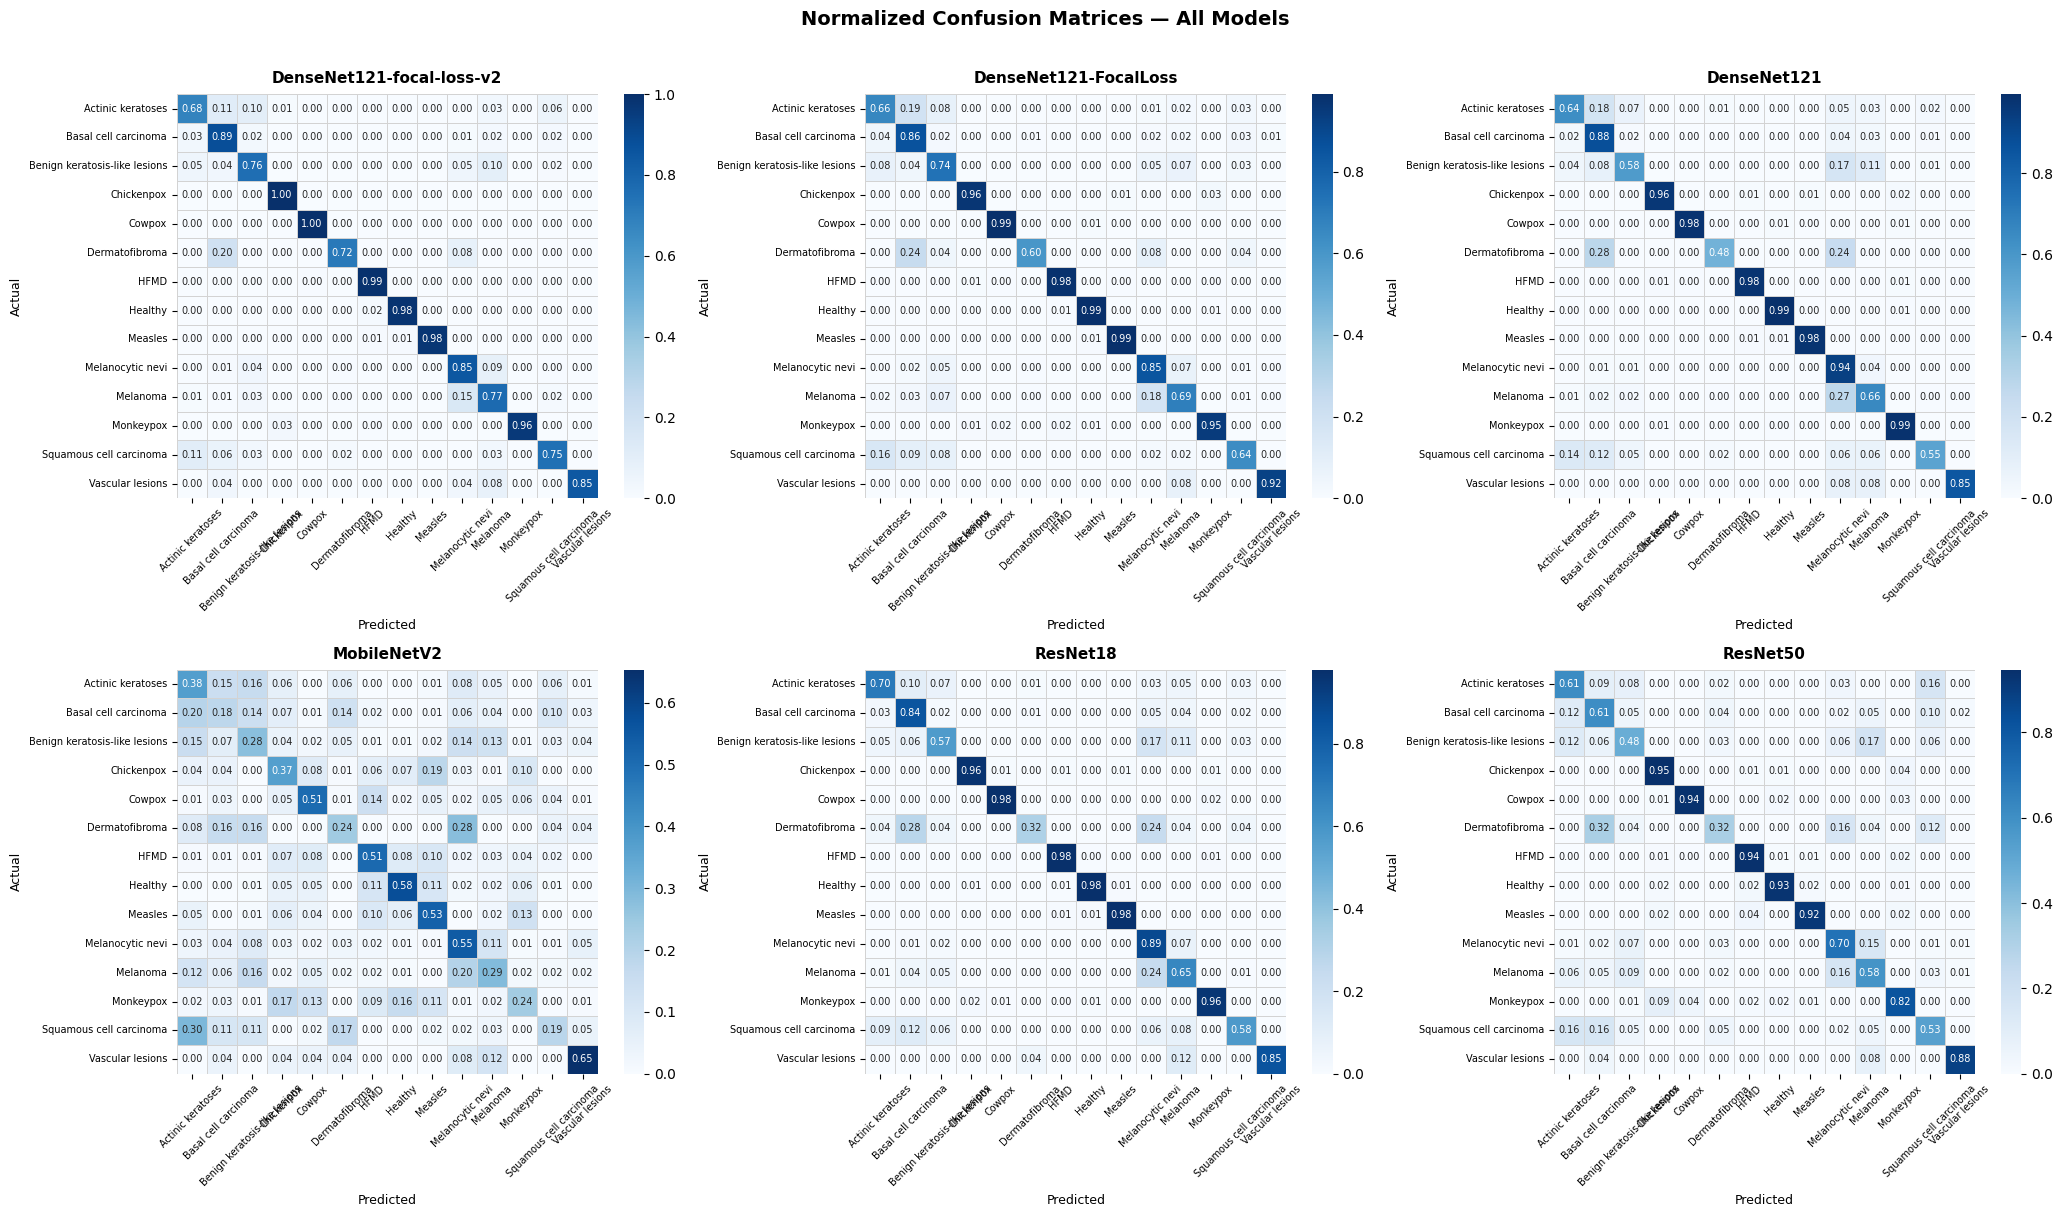

Saved → /kaggle/working/confusion_matrices_all.png


In [14]:
# ==============================================================================
# 9. CONFUSION MATRICES
# ==============================================================================
def plot_confusion_matrix(true_labels, pred_labels, class_names, model_name, ax):
    cm      = confusion_matrix(true_labels, pred_labels)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.4, linecolor="lightgrey",
        annot_kws={"size": 7},
    )
    ax.set_title(model_name, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual",    fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)
 
 
if all_true:
    n_models = len(all_true)
    ncols    = 3
    nrows    = -(-n_models // ncols)  # ceiling division
 
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 6))
    axes = axes.flatten() if n_models > 1 else [axes]
 
    for idx, (short_name, true_labels) in enumerate(all_true.items()):
        plot_confusion_matrix(
            true_labels, all_pred[short_name],
            target_names, short_name, axes[idx],
        )
 
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
 
    plt.suptitle(
        "Normalized Confusion Matrices — All Models",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrices_all.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved → /kaggle/working/confusion_matrices_all.png")
 

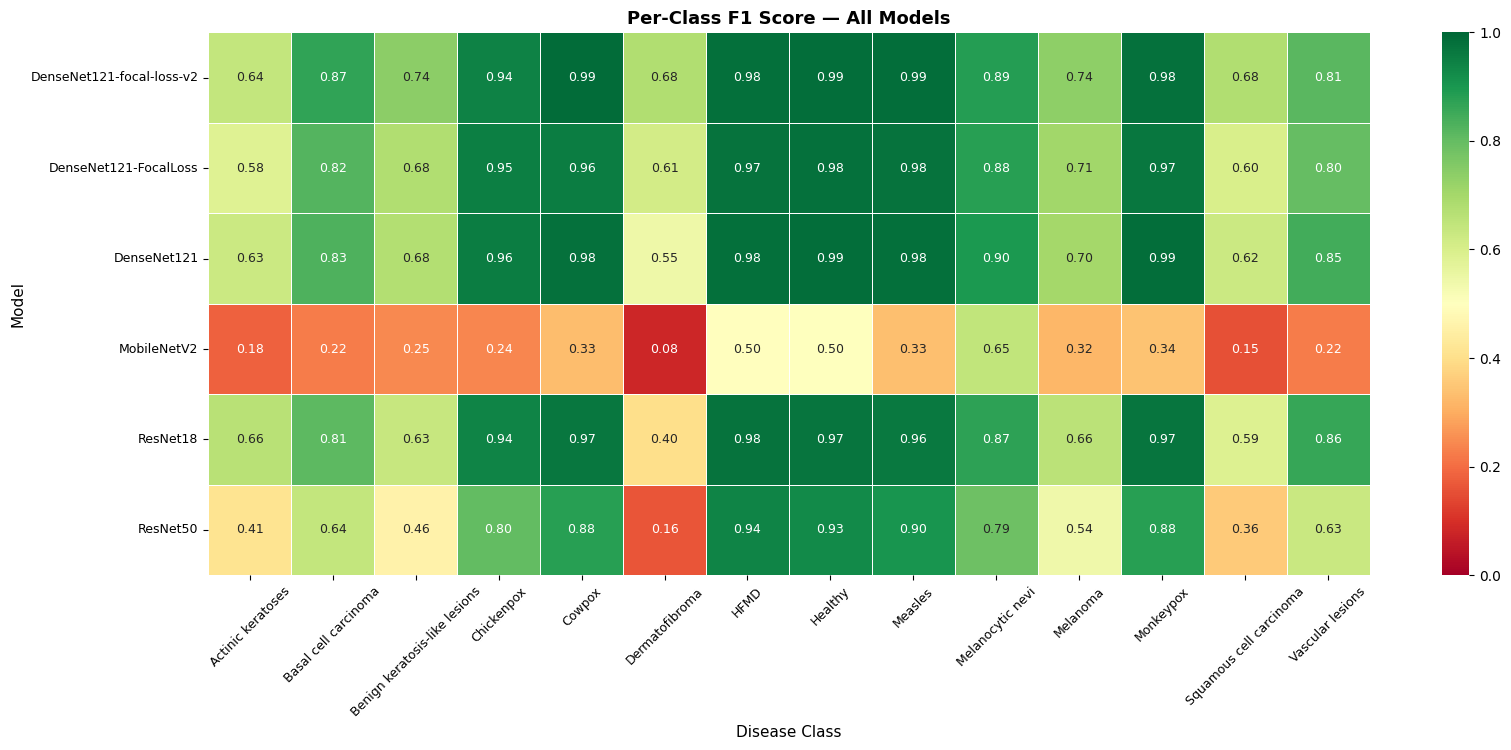

Saved → /kaggle/working/per_class_f1_heatmap.png


In [15]:
# ==============================================================================
# 10. PER-CLASS F1 HEATMAP
# ==============================================================================
if all_true:
    per_class_f1 = {}
    for short_name in all_true:
        report_dict = classification_report(
            all_true[short_name], all_pred[short_name],
            target_names=target_names,
            output_dict=True, zero_division=0,
        )
        per_class_f1[short_name] = {
            cls: report_dict[cls]["f1-score"] for cls in target_names
        }
 
    f1_df = pd.DataFrame(per_class_f1).T  # models × classes
 
    fig, ax = plt.subplots(figsize=(max(12, num_classes * 1.2), len(all_true) * 1.1 + 1))
    sns.heatmap(
        f1_df, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, ax=ax, linewidths=0.5,
        annot_kws={"size": 9},
    )
    ax.set_title("Per-Class F1 Score — All Models", fontsize=13, fontweight="bold")
    ax.set_xlabel("Disease Class", fontsize=11)
    ax.set_ylabel("Model",         fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)
    plt.tight_layout()
    plt.savefig("/kaggle/working/per_class_f1_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved → /kaggle/working/per_class_f1_heatmap.png")
 

In [16]:
# ==============================================================================
# 11. DONE
# ==============================================================================
print("\n✅ All evaluations complete!")
print("\nOutput files saved to /kaggle/working/:")
print("  • model_comparison_summary.csv  — metric table")
print("  • model_comparison_bar.png      — grouped bar chart")
print("  • confusion_matrices_all.png    — confusion matrix grid")
print("  • per_class_f1_heatmap.png      — per-class F1 heatmap")
 


✅ All evaluations complete!

Output files saved to /kaggle/working/:
  • model_comparison_summary.csv  — metric table
  • model_comparison_bar.png      — grouped bar chart
  • confusion_matrices_all.png    — confusion matrix grid
  • per_class_f1_heatmap.png      — per-class F1 heatmap
